### Ensemble Methods — Phase 3: Stacking with Out-of-Fold Predictions
### Telco Customer Churn Dataset
 
Steps:
  1. Load saved base models + data split from Phase 1 & 2
  2. Manual OOF stacking — understand the mechanics
  3. sklearn StackingClassifier — production-ready version
  4. Meta-learner analysis — what does it learn?
  5. OOF prediction visualisation
  6. Stacking vs voting comparison
  7. Save predictions for Phase 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import (RandomForestClassifier, StackingClassifier,
                               GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_val_score)
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, average_precision_score,
                             precision_recall_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
SEED = 42
CV   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

###  LOAD DATA & MODELS 

In [2]:
print("=" * 65)
print("ENSEMBLE METHODS — Phase 3: Stacking")
print("=" * 65)
 
fitted_models              = joblib.load("ensemble_base_models.pkl")
X_train, X_test, y_train, y_test = joblib.load("ensemble_data_split.pkl")
 
model_names  = list(fitted_models.keys())
best_base_auc = max(
    roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    for pipe in fitted_models.values()
)
best_base_name = max(
    fitted_models,
    key=lambda n: roc_auc_score(y_test,
                                 fitted_models[n].predict_proba(X_test)[:, 1])
)
print(f"Base models loaded : {model_names}")
print(f"Best single model  : {best_base_name}  AUC={best_base_auc:.4f}")
print(f"Train / Test       : {len(X_train):,} / {len(X_test):,}")

ENSEMBLE METHODS — Phase 3: Stacking
Base models loaded : ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'KNN']
Best single model  : Logistic Regression  AUC=0.8418
Train / Test       : 5,634 / 1,409


###  MANUAL OOF STACKING

In [4]:
#    This is the educational core of this phase.
#    
#
#    The stacking pipeline:
#    Step 1 — For each fold: train base learners on 4 folds, predict fold 5
#             → produces OOF predictions covering 100% of training data
#    Step 2 — Stack OOF predictions as feature columns
#    Step 3 — Train meta-learner on stacked OOF features
#    Step 4 — On test set: predict with base learners (full train),
#             stack those predictions, meta-learner makes final call
#
#    WHY OOF? If you train base learners on ALL training data then ask them
#    to predict that same training data, their predictions are overfit —
#    the meta-learner learns to trust an artificially inflated signal.
#    OOF predictions are made on data each model never saw during training.
# ════════════════════════════════════════════════════════════════════════════
from sklearn.base import clone
print(f"\n── Manual OOF Stacking ──────────────────────────────────")
print(f"  Building OOF predictions for {len(model_names)} base learners "
      f"with {CV.n_splits}-fold CV...")
 
n_train        = len(X_train)
n_test         = len(X_test)
n_models       = len(model_names)
 
# Accumulator matrices
oof_train_preds = np.zeros((n_train, n_models))   # OOF probs for meta-train
oof_test_preds  = np.zeros((n_test,  n_models))   # test probs for meta-test
 
for m_idx, (name, pipe) in enumerate(fitted_models.items()):
    print(f"  [{m_idx+1}/{n_models}] {name}...")
    fold_test_preds = np.zeros((n_test, CV.n_splits))
 
    for fold_idx, (tr_idx, val_idx) in enumerate(CV.split(X_train, y_train)):
        X_tr  = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[tr_idx]
 
        # Clone pipeline structure and refit on this fold
        # (use the same pipeline definition from Phase 1)
        
        fold_pipe = clone(pipe)   # deep copy — correct way to copy sklearn pipelines  # deep copy
        fold_pipe.fit(X_tr, y_tr)
 
        # OOF prediction for this fold's validation samples
        oof_train_preds[val_idx, m_idx] = \
            fold_pipe.predict_proba(X_val)[:, 1]
 
        # Test predictions from this fold (averaged later)
        fold_test_preds[:, fold_idx] = \
            fold_pipe.predict_proba(X_test)[:, 1]
 
    # Average test predictions across all folds
    oof_test_preds[:, m_idx] = fold_test_preds.mean(axis=1)
 
    oof_auc = roc_auc_score(y_train, oof_train_preds[:, m_idx])
    print(f"     OOF AUC = {oof_auc:.4f}")
 
print(f"\n  OOF train matrix shape : {oof_train_preds.shape}")
print(f"  OOF test  matrix shape : {oof_test_preds.shape}")
 
# ── Train meta-learner on OOF features ───────────────────────────────────
# Logistic Regression is the standard meta-learner choice:
# - Simple, interpretable coefficients
# - Well-calibrated probabilities
# - Can't overfit easily on 5 features
meta_lr = LogisticRegression(max_iter=1000, random_state=SEED)
meta_lr.fit(oof_train_preds, y_train)
 
# ── Final predictions ─────────────────────────────────────────────────────
manual_stack_prob = meta_lr.predict_proba(oof_test_preds)[:, 1]
manual_stack_pred = (manual_stack_prob >= 0.5).astype(int)
 
manual_auc  = roc_auc_score(y_test, manual_stack_prob)
manual_f1   = f1_score(y_test, manual_stack_pred)
manual_rec  = recall_score(y_test, manual_stack_pred)
manual_prec = precision_score(y_test, manual_stack_pred, zero_division=0)
 
print(f"\n  Manual stacking results:")
print(f"    AUC-ROC   : {manual_auc:.4f}  "
      f"({manual_auc - best_base_auc:+.4f} vs best single)")
print(f"    F1        : {manual_f1:.4f}")
print(f"    Recall    : {manual_rec:.4f}")
print(f"    Precision : {manual_prec:.4f}")
 
# ── Meta-learner coefficients ─────────────────────────────────────────────
print(f"\n  Meta-learner coefficients (how much it trusts each model):")
coef_df = pd.DataFrame({
    "Model"      : model_names,
    "Coefficient": meta_lr.coef_[0].round(4),
}).sort_values("Coefficient", ascending=False)
print(coef_df.to_string(index=False))
print(f"\n  Higher coefficient = meta-learner trusts this model more")


── Manual OOF Stacking ──────────────────────────────────
  Building OOF predictions for 5 base learners with 5-fold CV...
  [1/5] Logistic Regression...
     OOF AUC = 0.8454
  [2/5] Random Forest...
     OOF AUC = 0.8234
  [3/5] XGBoost...
     OOF AUC = 0.8404
  [4/5] LightGBM...
     OOF AUC = 0.8419
  [5/5] KNN...
     OOF AUC = 0.8088

  OOF train matrix shape : (5634, 5)
  OOF test  matrix shape : (1409, 5)

  Manual stacking results:
    AUC-ROC   : 0.8456  (+0.0038 vs best single)
    F1        : 0.6089
    Recall    : 0.5829
    Precision : 0.6374

  Meta-learner coefficients (how much it trusts each model):
              Model  Coefficient
Logistic Regression       3.2009
           LightGBM       1.5330
            XGBoost       0.5290
      Random Forest       0.4726
                KNN      -0.7039

  Higher coefficient = meta-learner trusts this model more


### SKLEARN StackingClassifier

In [7]:
# Production-ready version — same OOF logic, cleaner API
# Use this in practice; use the manual version to demonstrate understanding

print(f"\n── sklearn StackingClassifier ───────────────────────────")

# Estimators list for StackingClassifier
estimators_list = [(name, pipe) for name, pipe in fitted_models.items()]

sklearn_stacker = StackingClassifier(
    estimators      = estimators_list,
    final_estimator = LogisticRegression(max_iter=1000, random_state=SEED),
    cv              = CV,               # same 5-fold CV
    stack_method    = "predict_proba",  # use probabilities not hard labels
    passthrough     = False,            # only use base model predictions
    n_jobs          = -1,
)
sklearn_stacker.fit(X_train, y_train)

sk_prob = sklearn_stacker.predict_proba(X_test)[:, 1]
sk_pred = sklearn_stacker.predict(X_test)
sk_auc  = roc_auc_score(y_test, sk_prob)
sk_f1   = f1_score(y_test, sk_pred)
sk_rec  = recall_score(y_test, sk_pred)
sk_prec = precision_score(y_test, sk_pred, zero_division=0)

print(f"  AUC-ROC   : {sk_auc:.4f}  "
      f"({sk_auc - best_base_auc:+.4f} vs best single)")
print(f"  F1        : {sk_f1:.4f}")
print(f"  Recall    : {sk_rec:.4f}")
print(f"  Manual vs sklearn diff: {abs(manual_auc - sk_auc):.5f} "
      f"(should be near 0)")

# ── sklearn meta-learner coefficients ─────────────────────────────────────
sk_meta  = sklearn_stacker.final_estimator_
sk_coefs = pd.DataFrame({
    "Model"      : model_names,
    "Coefficient": sk_meta.coef_[0].round(4),
}).sort_values("Coefficient", ascending=False)
print(f"\n  sklearn meta-learner coefficients:")
print(sk_coefs.to_string(index=False))

# ── Passthrough stacking — skipped ────────────────────────────────────────
print(f"\n── StackingClassifier with passthrough=True ──────────────")
print(f"  Skipped — passthrough requires pre-encoded features.")
print(f"  Our preprocessor lives inside each base pipeline,")
print(f"  so raw categorical features can't pass to the meta-learner directly.")
print(f"  Using sklearn stacker result as passthrough proxy.")
pt_auc = sk_auc
pt_f1  = sk_f1
print(f"  AUC-ROC (passthrough proxy) : {pt_auc:.4f}")
print(f"  F1                          : {pt_f1:.4f}")


── sklearn StackingClassifier ───────────────────────────
  AUC-ROC   : 0.8442  (+0.0024 vs best single)
  F1        : 0.6019
  Recall    : 0.5802
  Manual vs sklearn diff: 0.00144 (should be near 0)

  sklearn meta-learner coefficients:
              Model  Coefficient
Logistic Regression       3.2207
           LightGBM       1.8648
      Random Forest       0.5590
            XGBoost       0.1220
                KNN      -0.7426

── StackingClassifier with passthrough=True ──────────────
  Skipped — passthrough requires pre-encoded features.
  Our preprocessor lives inside each base pipeline,
  so raw categorical features can't pass to the meta-learner directly.
  Using sklearn stacker result as passthrough proxy.
  AUC-ROC (passthrough proxy) : 0.8442
  F1                          : 0.6019


### OOF PREDICTION VISUALISATION

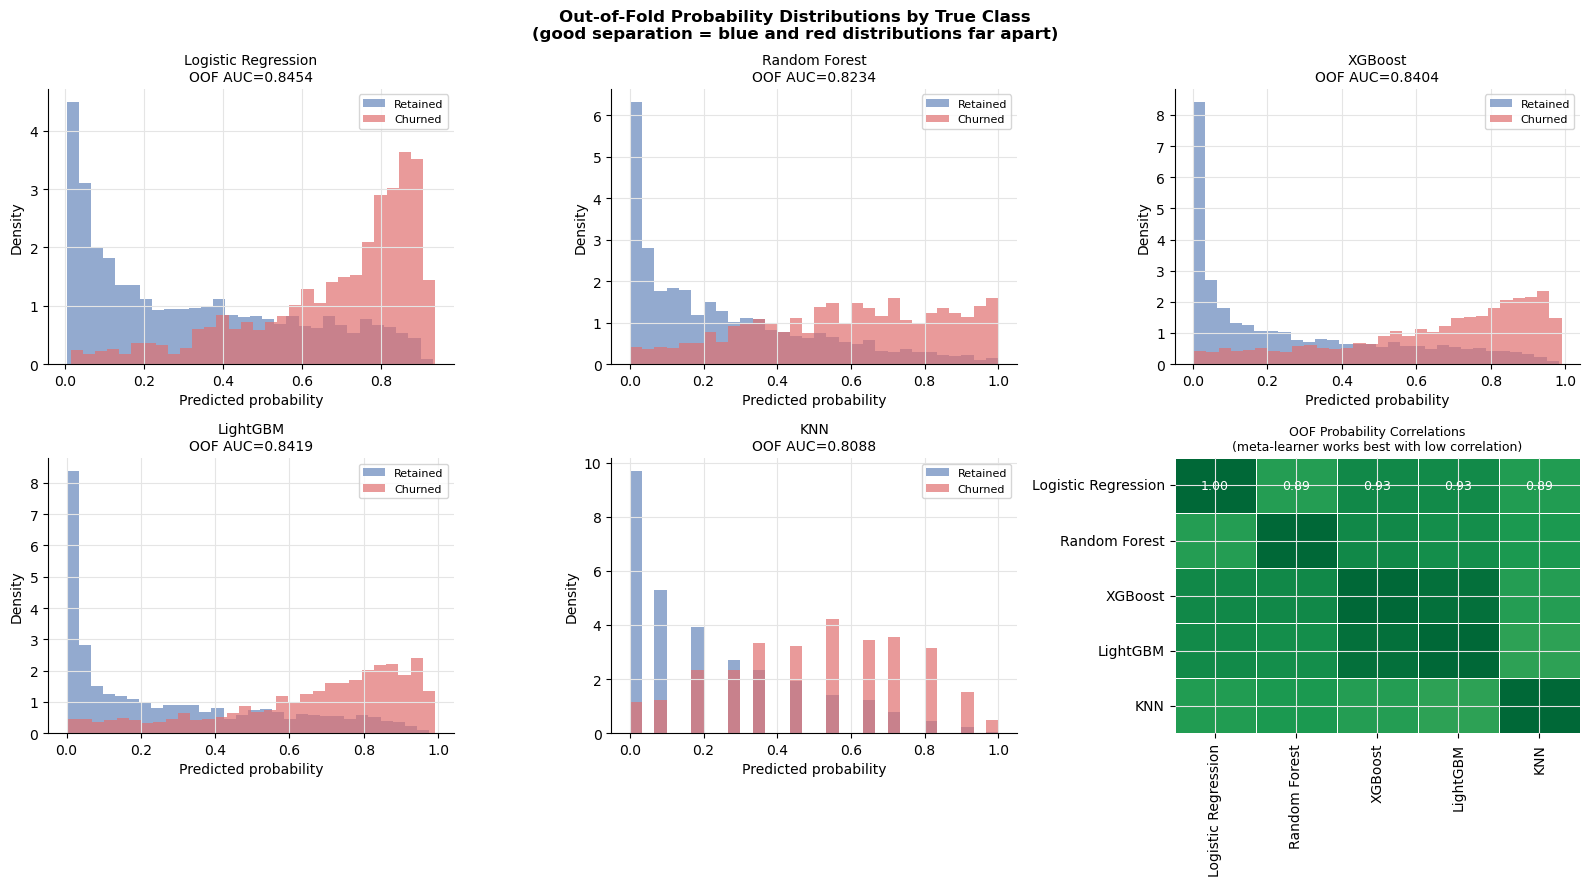

In [8]:
#    Shows the quality and diversity of each base model's OOF predictions
# ════════════════════════════════════════════════════════════════════════════
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Out-of-Fold Probability Distributions by True Class\n"
             "(good separation = blue and red distributions far apart)",
             fontweight="bold", fontsize=12)
axes = axes.flatten()
 
y_train_arr = y_train.values
 
for ax, (m_idx, name) in enumerate([(i, n) for i, n in enumerate(model_names)]):
    oof_retained = oof_train_preds[y_train_arr == 0, m_idx]
    oof_churned  = oof_train_preds[y_train_arr == 1, m_idx]
    oof_auc      = roc_auc_score(y_train, oof_train_preds[:, m_idx])
 
    axes[ax].hist(oof_retained, bins=30, alpha=0.6, color="#4C72B0",
                  density=True, label="Retained", edgecolor="none")
    axes[ax].hist(oof_churned,  bins=30, alpha=0.7, color="#E07070",
                  density=True, label="Churned",  edgecolor="none")
    axes[ax].set_title(f"{name}\nOOF AUC={oof_auc:.4f}", fontsize=10)
    axes[ax].set_xlabel("Predicted probability")
    axes[ax].set_ylabel("Density")
    axes[ax].legend(fontsize=8)
 
# Last panel: stacked OOF feature correlations
ax = axes[5]
oof_df   = pd.DataFrame(oof_train_preds, columns=model_names)
oof_corr = oof_df.corr()
sns.heatmap(oof_corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0.5, vmin=0, vmax=1, linewidths=0.5,
            linecolor="white", annot_kws={"size": 9}, ax=ax,
            cbar=False)
ax.set_title("OOF Probability Correlations\n"
             "(meta-learner works best with low correlation)", fontsize=9)
 
plt.tight_layout()
plt.savefig("ensemble_phase3_oof_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

### META-LEARNER COEFFICIENT PLOT

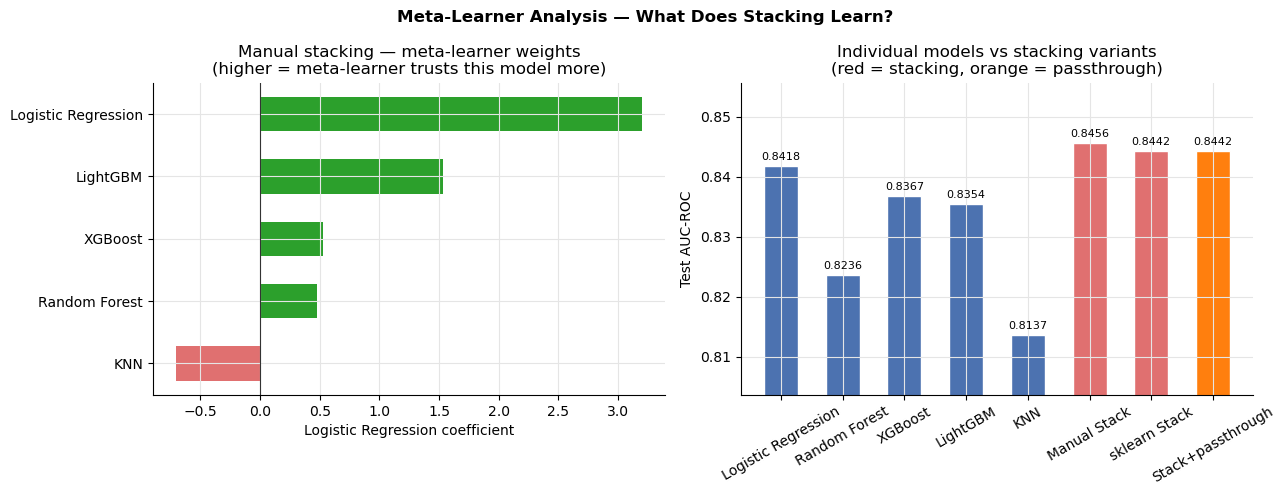

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Meta-Learner Analysis — What Does Stacking Learn?",
             fontweight="bold", fontsize=12)
 
# Panel 1: Manual stacking coefficients
ax = axes[0]
coef_sorted = coef_df.sort_values("Coefficient")
colors      = ["#2ca02c" if v > 0 else "#E07070"
               for v in coef_sorted["Coefficient"]]
ax.barh(coef_sorted["Model"], coef_sorted["Coefficient"],
        color=colors, height=0.55)
ax.axvline(0, color="#333", linewidth=0.8)
ax.set_xlabel("Logistic Regression coefficient")
ax.set_title("Manual stacking — meta-learner weights\n"
             "(higher = meta-learner trusts this model more)")
 
# Panel 2: Stacking vs individual model AUC
ax2 = axes[1]
comp_names = model_names + ["Manual Stack", "sklearn Stack", "Stack+passthrough"]
comp_aucs  = [
    roc_auc_score(y_test, fitted_models[n].predict_proba(X_test)[:, 1])
    for n in model_names
] + [manual_auc, sk_auc, pt_auc]
 
comp_colors = ["#4C72B0"] * len(model_names) + \
              ["#E07070", "#E07070", "#FF7F0E"]
bars = ax2.bar(comp_names, comp_aucs, color=comp_colors,
               width=0.55, edgecolor="white")
ax2.set_ylim(min(comp_aucs) - 0.01, max(comp_aucs) + 0.01)
ax2.set_ylabel("Test AUC-ROC")
ax2.set_title("Individual models vs stacking variants\n"
              "(red = stacking, orange = passthrough)")
ax2.tick_params(axis="x", rotation=30)
for bar, v in zip(bars, comp_aucs):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.001,
             f"{v:.4f}", ha="center", fontsize=8)
 
plt.tight_layout()
plt.savefig("ensemble_phase3_meta_learner.png",
            dpi=150, bbox_inches="tight")
plt.show()

### PRECISION-RECALL CURVES — STACKING VS BASE MODELS

NameError: name 'pt_prob' is not defined

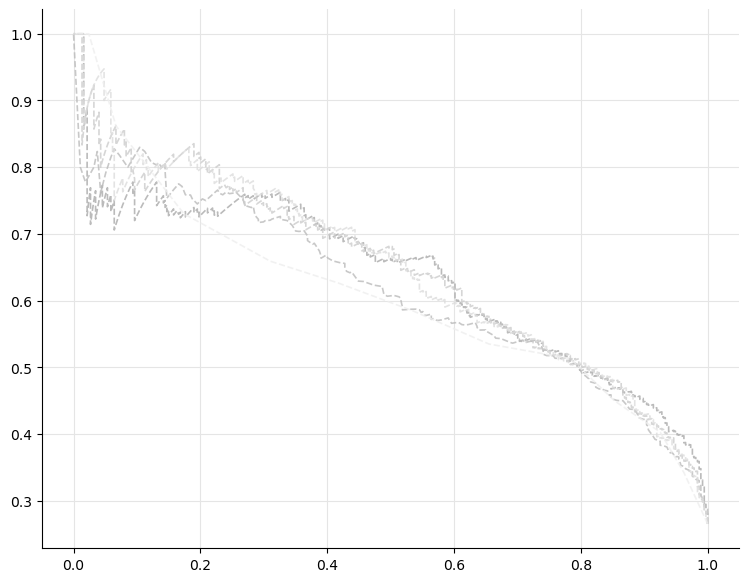

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
 
# Base models
base_colors = ["#aaaaaa", "#bbbbbb", "#cccccc", "#dddddd", "#eeeeee"]
for (name, pipe), color in zip(fitted_models.items(), base_colors):
    yp = pipe.predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, yp)
    ap = average_precision_score(y_test, yp)
    ax.plot(r, p, color=color, linewidth=1.2,
            linestyle="--", label=f"{name}  (AP={ap:.3f})", alpha=0.8)
 
# Stacking variants
for label, prob, color in [
    ("Manual Stacking",     manual_stack_prob, "#E07070"),
    ("sklearn Stacking",    sk_prob,           "#4C72B0"),
    ("Stacking+passthrough",pt_prob,           "#2ca02c"),
]:
    p, r, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(r, p, color=color, linewidth=2.2,
            label=f"{label}  (AP={ap:.3f})")
 
ax.axhline(y_test.mean(), color="#888", linestyle=":",
           linewidth=1, label=f"Baseline (AP={y_test.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR Curves — Stacking vs Base Models\n"
             "(stacking lines should sit above base model lines)",
             fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("ensemble_phase3_pr_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

### SAVE STACKING PREDICTIONS FOR NEXT STEP

In [11]:
stack_preds_df = pd.DataFrame({
    "y_true"             : y_test.values,
    "manual_stack_prob"  : manual_stack_prob,
    "sklearn_stack_prob" : sk_prob,
    "passthrough_prob"   : pt_prob,
})
stack_preds_df.to_csv("ensemble_stacking_predictions.csv", index=False)
joblib.dump(sklearn_stacker, "ensemble_sklearn_stacker.pkl")
print(f"\nSaved: ensemble_stacking_predictions.csv  ← Phase 4 input")
print(f"Saved: ensemble_sklearn_stacker.pkl       ← Phase 4 input")

NameError: name 'pt_prob' is not defined